In [1]:
import matplotlib.pyplot as plt
import pydicom
from pydicom import dcmread
import numpy as np
import matplotlib.pyplot as plt
import sys
import glob
from pathlib import Path
import sklearn
from sklearn.preprocessing import normalize, MinMaxScaler, MaxAbsScaler

In [2]:
# load the DICOM files
files = []
#print(f"glob: {sys.argv[1]}")
for fname in glob.glob("C:/Users/admin/DataSet/norma_anon/*", recursive=False):
    #print(f"loading: {fname}")
    files.append(pydicom.dcmread(fname))

print(f"file count: {len(files)}")

file count: 451


In [3]:
# skip files with no SliceLocation (eg scout views)
slices = []
skipcount = 0
for f in files:
    if hasattr(f, "SliceLocation"):
        slices.append(f)
    else:
        skipcount = skipcount + 1

print(f"skipped, no SliceLocation: {skipcount}")

# ensure they are in the correct order
slices = sorted(slices, key=lambda s: s.SliceLocation)

# pixel aspects, assuming all slices are the same
ps = slices[0].PixelSpacing
ss = slices[0].SliceThickness
ax_aspect = ps[1] / ps[0]
sag_aspect = ps[1] / ss
cor_aspect = ss / ps[0]

# create 3D array
img_shape = list(slices[0].pixel_array.shape)
img_shape.append(len(slices))
img3d = np.zeros(img_shape)
#scaler = MinMaxScaler()
scaler = MaxAbsScaler()
# fill 3D array with the images from the files
for i, s in enumerate(slices):
    img2d = s.pixel_array
    #img3d[:, :, i] = normalize(img2d, axis=1, norm='l1')
    #scaler.fit(img2d)
    img3d[:, :, i] = scaler.fit_transform(img2d)

img3d.shape

skipped, no SliceLocation: 0


(512, 512, 451)

In [4]:
#img3d_n = normalize(img3d, axis=1, norm='l1')
img3d.shape

(512, 512, 451)

In [5]:
print(img3d)

[[[ 0.  0.  0. ...  0.  0.  0.]
  [-1. -1. -1. ... -1. -1. -1.]
  [-1. -1. -1. ... -1. -1. -1.]
  ...
  [-1. -1. -1. ... -1. -1. -1.]
  [-1. -1. -1. ... -1. -1. -1.]
  [-1. -1. -1. ... -1. -1. -1.]]

 [[-1. -1. -1. ... -1. -1. -1.]
  [-1. -1. -1. ... -1. -1. -1.]
  [-1. -1. -1. ... -1. -1. -1.]
  ...
  [-1. -1. -1. ... -1. -1. -1.]
  [-1. -1. -1. ... -1. -1. -1.]
  [-1. -1. -1. ... -1. -1. -1.]]

 [[-1. -1. -1. ... -1. -1. -1.]
  [-1. -1. -1. ... -1. -1. -1.]
  [-1. -1. -1. ... -1. -1. -1.]
  ...
  [-1. -1. -1. ... -1. -1. -1.]
  [-1. -1. -1. ... -1. -1. -1.]
  [-1. -1. -1. ... -1. -1. -1.]]

 ...

 [[-1. -1. -1. ... -1. -1. -1.]
  [-1. -1. -1. ... -1. -1. -1.]
  [-1. -1. -1. ... -1. -1. -1.]
  ...
  [-1. -1. -1. ... -1. -1. -1.]
  [-1. -1. -1. ... -1. -1. -1.]
  [-1. -1. -1. ... -1. -1. -1.]]

 [[-1. -1. -1. ... -1. -1. -1.]
  [-1. -1. -1. ... -1. -1. -1.]
  [-1. -1. -1. ... -1. -1. -1.]
  ...
  [-1. -1. -1. ... -1. -1. -1.]
  [-1. -1. -1. ... -1. -1. -1.]
  [-1. -1. -1. ... -1. -1. -

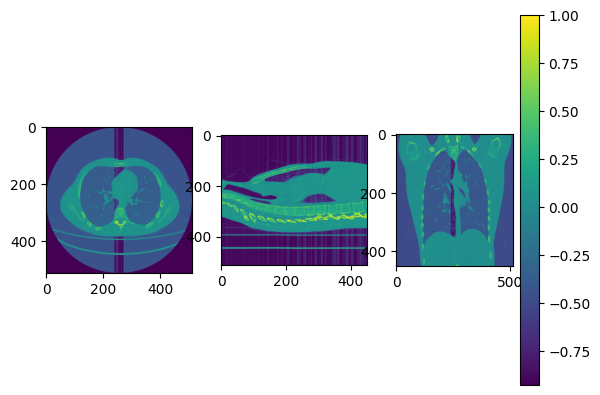

In [6]:
# pixel aspects, assuming all slices are the same
ps = slices[0].PixelSpacing
ss = slices[0].SliceThickness
ax_aspect = ps[1] / ps[0]
sag_aspect = ps[1] / ss
cor_aspect = ss / ps[0]

# plot 3 orthogonal slices
a1 = plt.subplot(1, 3, 1)
plt.imshow(img3d[:, :, img_shape[2] // 2])
a1.set_aspect(ax_aspect)

a2 = plt.subplot(1, 3, 2)
plt.imshow(img3d[:, img_shape[1] // 2, :])
a2.set_aspect(sag_aspect)

a3 = plt.subplot(1, 3, 3)
plt.imshow(img3d[img_shape[0] // 2, :, :].T)
a3.set_aspect(cor_aspect)
plt.colorbar()
plt.show()

In [7]:
directory = Path("C:/Users/admin/DataSet/pneumotorax_anon")
for item in directory.iterdir(): 
    ds = dcmread(item)
    arr = ds.pixel_array
    #print(arr)
    #plt.imshow(arr, cmap="gray")
    #plt.show()
#print(f"file count: {len(item)}")

In [8]:
arr = ds.pixel_array
arr.shape

(476, 512, 512)

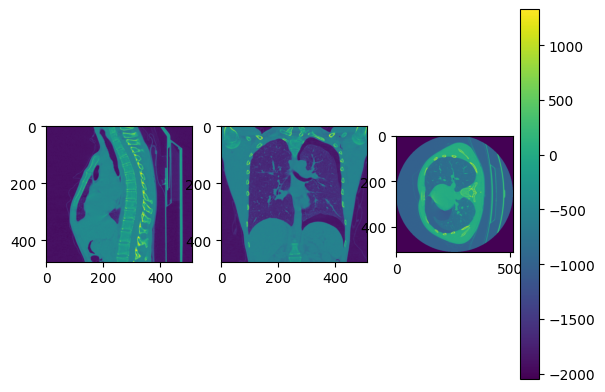

In [9]:
# plot 3 orthogonal slices
a1 = plt.subplot(1, 3, 1)
plt.imshow(arr[:, :, arr.shape[2] // 2])
#a1.set_aspect(ax_aspect)

a2 = plt.subplot(1, 3, 2)
plt.imshow(arr[:, arr.shape[1] // 2, :])
#a2.set_aspect(sag_aspect)

a3 = plt.subplot(1, 3, 3)
plt.imshow(arr[arr.shape[0] // 2, :, :].T)
#a3.set_aspect(cor_aspect)
plt.colorbar()
plt.show()

In [10]:
# load the DICOM files
files2 = []
#print(f"glob: {sys.argv[1]}")
for fname in glob.glob("C:/Users/admin/DataSet/pneumonia_anon/*", recursive=False):
    #print(f"loading: {fname}")
    files2.append(pydicom.dcmread(fname))

print(f"file count: {len(files2)}")

file count: 367


In [11]:
# skip files with no SliceLocation (eg scout views)
slices2 = []
skipcount = 0
for f in files2:
    if hasattr(f, "SliceLocation"):
        slices2.append(f)
    else:
        skipcount = skipcount + 1

print(f"skipped, no SliceLocation: {skipcount}")

# ensure they are in the correct order
slices2 = sorted(slices2, key=lambda s: s.SliceLocation)

# pixel aspects, assuming all slices are the same
ps2 = slices2[0].PixelSpacing
ss2 = slices2[0].SliceThickness
ax_aspect = ps2[1] / ps2[0]
sag_aspect = ps2[1] / ss2
cor_aspect = ss2 / ps2[0]

# create 3D array
img_shape = list(slices2[0].pixel_array.shape)
img_shape.append(len(slices2))
img3d = np.zeros(img_shape)
scaler = MaxAbsScaler()
# fill 3D array with the images from the files
for i, s in enumerate(slices2):
    img2d = s.pixel_array
    #img3d[:, :, i] = normalize(img2d, axis=1, norm='l1')
    img3d[:, :, i] = scaler.fit_transform(img2d)

img3d.shape

skipped, no SliceLocation: 0


(512, 512, 367)

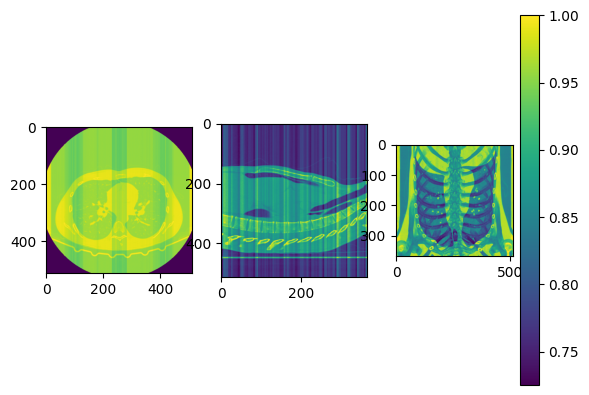

In [12]:
# plot 3 orthogonal slices
a1 = plt.subplot(1, 3, 1)
plt.imshow(img3d[:, :, img_shape[2] // 2])
a1.set_aspect(ax_aspect)

a2 = plt.subplot(1, 3, 2)
plt.imshow(img3d[:, img_shape[1] // 2, :])
a2.set_aspect(sag_aspect)

a3 = plt.subplot(1, 3, 3)
plt.imshow(img3d[img_shape[0] // 2, :, :].T)
a3.set_aspect(cor_aspect)
plt.colorbar()
plt.show()